In [1]:
%load_ext autotime

import scarf
scarf.__version__

'1.0.0'

time: 1.09 s (started: 2026-06-28 22:56:35 +02:00)


In [2]:
scarf.fetch_dataset(
    dataset_name='kang_15K_pbmc_rnaseq',
    save_path='scarf_datasets',
    as_zarr=True
)

scarf.fetch_dataset(
    dataset_name='kang_14K_ifnb-pbmc_rnaseq', 
    save_path='scarf_datasets',
    as_zarr=True
)

time: 24.6 s (started: 2026-06-28 22:56:36 +02:00)


In [3]:
ds_ctrl = scarf.DataStore(
    'scarf_datasets/kang_15K_pbmc_rnaseq/data.zarr/',
    nthreads=4
)

ds_ctrl

DataStore has 8487 (14619) cells with 1 assays: RNA
   Cell metadata:
            'I', 'ids', 'names', 'RNA_percentRibo', 'RNA_percentMito', 
            'RNA_nFeatures', 'RNA_unified_tSNE2', 'RNA_nCounts', 'cluster_labels', 'RNA_unified_UMAP1', 
            'RNA_leiden_cluster', 'RNA_UMAP2', 'RNA_unified_tSNE1', 'RNA_UMAP1', 'RNA_unified_UMAP2', 
          
   RNA assay has 11352 (35635) features and following metadata:
            'I', 'ids', 'names', 'dropOuts', 'nCells', 
            'I__hvgs'
      Projected samples:
            'stim'
      Co-embeddings:
            'unified_tSNE', 'unified_UMAP'

time: 253 ms (started: 2026-06-28 22:57:00 +02:00)


In [4]:
ds_stim = scarf.DataStore(
    'scarf_datasets/kang_14K_ifnb-pbmc_rnaseq/data.zarr',
    nthreads=4
)

ds_stim

DataStore has 10111 (14446) cells with 1 assays: RNA
   Cell metadata:
            'I', 'ids', 'names', 'RNA_nCounts', 'RNA_UMAP2', 
            'RNA_percentRibo', 'transferred_labels', 'RNA_percentMito', 'cluster_labels', 'RNA_nFeatures', 
            'RNA_leiden_cluster', 'RNA_UMAP1'
   RNA assay has 11051 (35635) features and following metadata:
            'I', 'ids', 'names', 'I__hvgs', 'dropOuts', 
            'nCells'

time: 212 ms (started: 2026-06-28 22:57:00 +02:00)


In [5]:
scarf.AssayMerge(
    zarr_path='scarf_datasets/kang_merged_pbmc_rnaseq.zarr',
    assays=[ds_ctrl.RNA, ds_stim.RNA],
    names=['ctrl', 'stim'],
    merge_assay_name='RNA',
    overwrite=True
).dump()

Writing data from assay 1/2 to merged file:   0%|                                                             …

Writing data from assay 2/2 to merged file:   0%|                                                             …

time: 12.6 s (started: 2026-06-28 22:57:01 +02:00)


In [6]:
ds = scarf.DataStore(
    'scarf_datasets/kang_merged_pbmc_rnaseq.zarr',
    nthreads=4
)

(RNA) Computing nCells and dropOuts:   0%|                                                                    …

(RNA) Computing nCounts:   0%|                                                                                …

(RNA) Computing nFeatures:   0%|                                                                              …

(RNA) Computing RNA_percentMito:   0%|                                                                        …

(RNA) Computing RNA_percentRibo:   0%|                                                                        …

time: 9.94 s (started: 2026-06-28 22:57:13 +02:00)


In [7]:
ds

DataStore has 29065 (29065) cells with 1 assays: RNA
   Cell metadata:
            'I', 'ids', 'names', 'orig_RNA_unified_UMAP1', 'orig_RNA_nCounts', 
            'orig_RNA_UMAP2', 'orig_RNA_percentMito', 'orig_RNA_percentRibo', 'RNA_percentMito', 'orig_RNA_UMAP1', 
            'orig_cluster_labels', 'orig_RNA_unified_tSNE1', 'RNA_nCounts', 'orig_transferred_labels', 'RNA_nFeatures', 
            'orig_RNA_unified_tSNE2', 'RNA_percentRibo', 'orig_RNA_nFeatures', 'orig_RNA_leiden_cluster', 'orig_RNA_unified_UMAP2', 
          
   RNA assay has 12450 (35635) features and following metadata:
            'I', 'ids', 'names', 'dropOuts', 'nCells', 
          

time: 69.6 ms (started: 2026-06-28 22:57:23 +02:00)


In [8]:
ds.cells.head()

,I,ids,names,orig_RNA_unified_tSNE1,orig_RNA_percentRibo,RNA_percentMito,orig_RNA_nCounts,orig_RNA_UMAP2,orig_RNA_UMAP1,orig_RNA_unified_UMAP1,orig_cluster_labels,orig_RNA_percentMito,orig_RNA_nFeatures,RNA_nCounts,orig_RNA_unified_tSNE2,orig_RNA_unified_UMAP2,orig_transferred_labels,RNA_percentRibo,orig_RNA_leiden_cluster,RNA_nFeatures
0,True,ctrl__TGTTAAGACACTGA-1,TGTTAAGACACTGA-1,NaN,20.034843,0.000000,574.0,NaN,NaN,NaN,nan,0.000000,304.0,574.0,NaN,NaN,nan,20.034843,-1,304.0
1,True,ctrl__TCACCCGAGCTATG-1,TCACCCGAGCTATG-1,NaN,0.059453,0.000000,1682.0,NaN,NaN,NaN,nan,0.000000,62.0,1682.0,NaN,NaN,nan,0.059453,-1,62.0
2,True,ctrl__TCACCCGAACCACA-1,TCACCCGAACCACA-1,-6.717438,31.763699,0.171233,1168.0,-5.990341,-1.768571,-3.079283,CD4 Memory T,0.171233,434.0,1168.0,-3.450251,-2.952994,nan,31.763699,1,434.0
3,True,ctrl__TGTAGTCTACCAGT-1,TGTAGTCTACCAGT-1,-3.214800,32.483781,0.185357,2158.0,-12.830768,-3.052445,-0.461304,CD8 T,0.185357,837.0,2158.0,-25.234907,-14.389237,nan,32.483781,7,837.0
4,True,ctrl__TATCAGCTAGTAGA-1,TATCAGCTAGTAGA-1,-18.614890,34.695341,0.143369,1395.0,-5.425503,-12.654625,-12.853556,B,0.143369,592.0,1395.0,-5.506958,-4.725232,nan,34.695341,5,592.0


time: 429 ms (started: 2026-06-28 22:57:23 +02:00)


In [9]:
ds.cells.insert(
    column_name='sample_id',
    values=[x.split('__')[0] for x in ds.cells.fetch_all('ids')],
    overwrite=True
)

time: 54.8 ms (started: 2026-06-28 22:57:23 +02:00)


In [10]:
ctrl_labels = list(ds_ctrl.cells.fetch_all('cluster_labels'))
stim_labels = list(ds_stim.cells.fetch_all('cluster_labels'))

ds.cells.insert(
    column_name='imported_labels',
    values=ctrl_labels + stim_labels,
    overwrite=True
)

time: 79.9 ms (started: 2026-06-28 22:57:23 +02:00)


In [11]:
ctrl_valid_cells = list(ds_ctrl.cells.fetch_all('I'))
stim_valid_cells = list(ds_stim.cells.fetch_all('I'))

ds.cells.update_key(
    values=ctrl_valid_cells + stim_valid_cells,
    key='I'
)

time: 85.8 ms (started: 2026-06-28 22:57:23 +02:00)


In [12]:
ds.cells.to_pandas_dataframe(
    ['sample_id'],
    key='I'
)['sample_id'].value_counts()

sample_id
ctrl    9441
stim    9157
Name: count, dtype: int64

time: 68.6 ms (started: 2026-06-28 22:57:23 +02:00)


INFO: Calculating summary statistics


(RNA) Computing feature stats:   0%|                                                                          …

INFO: Calculating HVGs


INFO: 2000 genes marked as HVGs


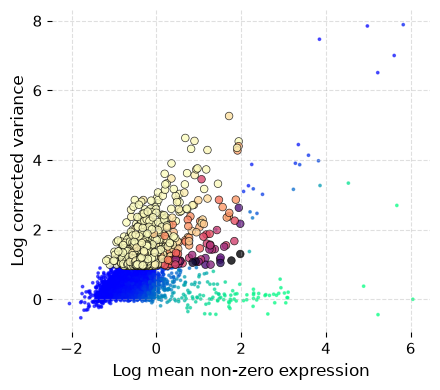

time: 6.18 s (started: 2026-06-28 22:57:23 +02:00)


In [13]:
ds.mark_hvgs(
    min_cells=10,
    top_n=2000,
    min_mean=-3, 
    max_mean=2,
    max_var=6
)

In [14]:
ds.make_graph(
    feat_key='hvgs',
    k=21, 
    dims=25,
    n_centroids=100
)

INFO: make_graph step 1/7: normalize expression matrix (computing)


Writing data to normed__I__hvgs/data:   0%|                                                                   …

INFO: make_graph step 1/7: normalize expression matrix finished in 4.1s (computing)


INFO: make_graph step 2/7: normalization statistics (computing)


Calculating mean and std. dev. of norm. data:   0%|                                                           …

...

INFO: ANN recall: 99.88%


INFO: make_graph step 7/7: finalize graph metadata (computing)


INFO: make_graph step 7/7: finalize graph metadata finished in 0.0s (computing)


INFO: make_graph finished in 36.9s (7/7 steps, 36.8s in logged steps)


time: 36.9 s (started: 2026-06-28 22:57:30 +02:00)


In [15]:
ds.run_umap(
    n_epochs=250, 
    spread=5,
    min_dist=1,
    parallel=True
)

Training UMAP:   0%|                                                                                          …

time: 8.83 s (started: 2026-06-28 22:58:06 +02:00)


In [16]:
ds.cells.head()

,I,ids,names,orig_RNA_UMAP2,orig_RNA_percentRibo,orig_RNA_nCounts,orig_RNA_unified_UMAP1,orig_cluster_labels,orig_RNA_UMAP1,orig_RNA_percentMito,...,RNA_nCounts,orig_RNA_unified_tSNE2,orig_transferred_labels,RNA_percentRibo,RNA_UMAP2,orig_RNA_unified_UMAP2,orig_RNA_nFeatures,imported_labels,sample_id,RNA_UMAP1
0,True,ctrl__TGTTAAGACACTGA-1,TGTTAAGACACTGA-1,NaN,20.034843,574.0,NaN,nan,NaN,0.000000,...,574.0,NaN,nan,20.034843,-22.689802,NaN,304.0,CD4 naive T,ctrl,-11.194890
1,True,ctrl__TCACCCGAGCTATG-1,TCACCCGAGCTATG-1,NaN,0.059453,1682.0,NaN,nan,NaN,0.000000,...,1682.0,NaN,nan,0.059453,33.028034,NaN,62.0,CD 14 Mono,ctrl,-6.803555
2,True,ctrl__TCACCCGAACCACA-1,TCACCCGAACCACA-1,-5.990341,31.763699,1168.0,-3.079283,CD4 Memory T,-1.768571,0.171233,...,1168.0,-3.450251,nan,31.763699,4.322801,-2.952994,434.0,CD 14 Mono,ctrl,-24.367174
3,True,ctrl__TGTAGTCTACCAGT-1,TGTAGTCTACCAGT-1,-12.830768,32.483781,2158.0,-0.461304,CD8 T,-3.052445,0.185357,...,2158.0,-25.234907,nan,32.483781,-13.416261,-14.389237,837.0,CD 14 Mono,ctrl,-17.196260
4,False,ctrl__TATCAGCTAGTAGA-1,TATCAGCTAGTAGA-1,-5.425503,34.695341,1395.0,-12.853556,B,-12.654625,0.143369,...,1395.0,-5.506958,nan,34.695341,NaN,-4.725232,592.0,nan,ctrl,NaN


time: 428 ms (started: 2026-06-28 22:58:14 +02:00)


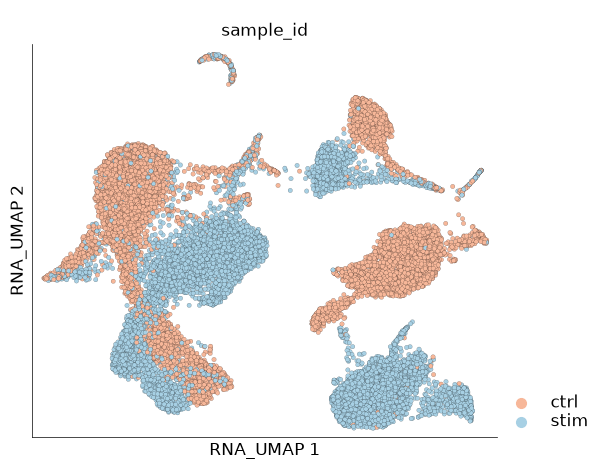

time: 428 ms (started: 2026-06-28 22:58:15 +02:00)


In [17]:
ds.plot_layout(
    layout_key='RNA_UMAP',
    color_by='sample_id',
    cmap='RdBu', 
    legend_ondata=False
)

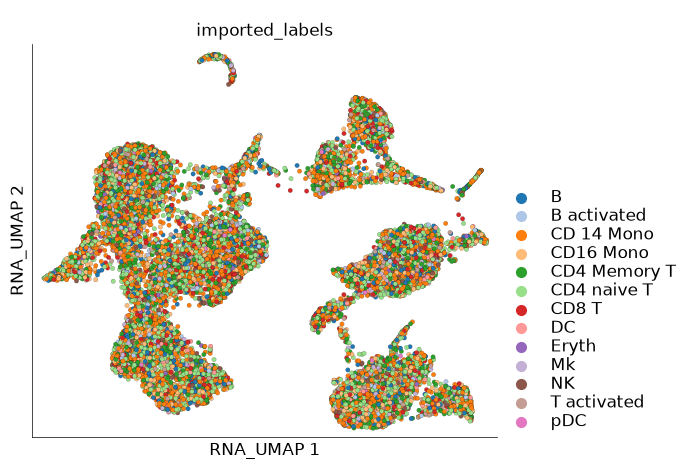

time: 470 ms (started: 2026-06-28 22:58:15 +02:00)


In [18]:
ds.plot_layout(
    layout_key='RNA_UMAP', 
    color_by='imported_labels',
    legend_ondata=False
)

In [19]:
ds.cells.insert(
    column_name=f'is_ctrl',
    values=(ds.cells.fetch_all('sample_id') == 'ctrl'),
    overwrite=True
)

time: 39 ms (started: 2026-06-28 22:58:15 +02:00)


In [20]:
ds.make_graph(
    feat_key='hvgs',
    k=21, 
    dims=25,
    n_centroids=100,
    pca_cell_key='is_ctrl'
)

INFO: make_graph step 1/7: normalize expression matrix (reusing cached)


INFO: Using existing normalized data with cell key I and feat key I__hvgs


INFO: make_graph step 1/7: normalize expression matrix finished in 0.1s (reusing cached)


INFO: make_graph step 2/7: normalization statistics (reusing cached)


INFO: make_graph step 2/7: normalization statistics finished in 0.0s (reusing cached)


...

INFO: ANN recall: 99.87%


INFO: make_graph step 7/7: finalize graph metadata (computing)


INFO: make_graph step 7/7: finalize graph metadata finished in 0.0s (computing)


INFO: make_graph finished in 15.0s (7/7 steps, 15.0s in logged steps)


time: 15.1 s (started: 2026-06-28 22:58:15 +02:00)


In [21]:
ds.run_umap(
    n_epochs=250, 
    spread=5,
    min_dist=1,
    parallel=True,
    label='pUMAP'
)

Training UMAP:   0%|                                                                                          …

time: 7.81 s (started: 2026-06-28 22:58:31 +02:00)


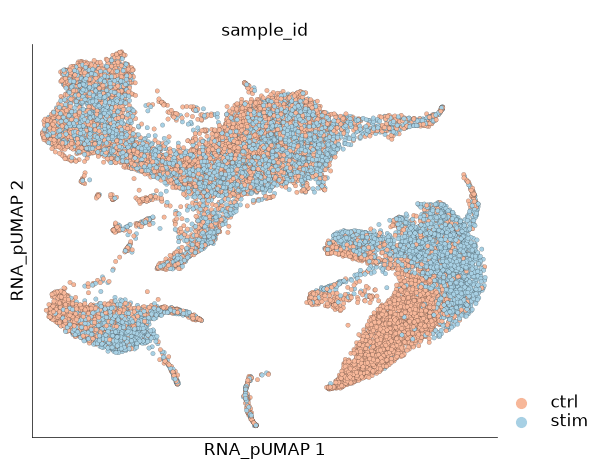

time: 445 ms (started: 2026-06-28 22:58:38 +02:00)


In [22]:
ds.plot_layout(
    layout_key='RNA_pUMAP',
    color_by='sample_id',
    cmap='RdBu',
    legend_ondata=False
)

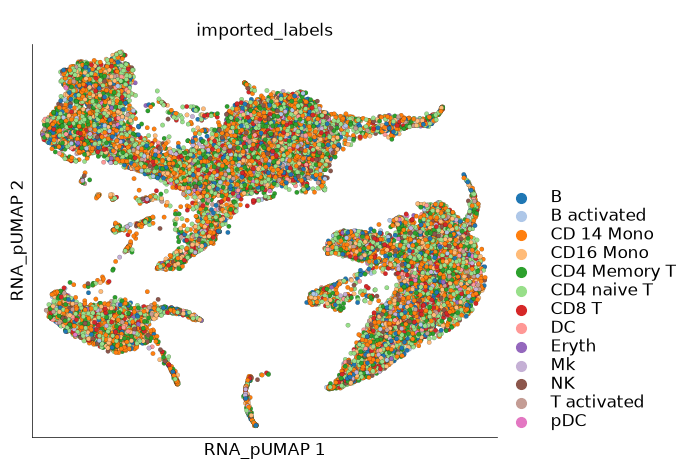

time: 489 ms (started: 2026-06-28 22:58:39 +02:00)


In [23]:
ds.plot_layout(
    layout_key='RNA_pUMAP',
    color_by='imported_labels',
    legend_ondata=False
)

In [24]:
ds.make_graph(
    feat_key='hvgs',
    k=21,
    dims=25,
    n_centroids=100,
    harmonize=True,
    batch_columns=['sample_id'],
)

ds.run_umap(
    n_epochs=250,
    spread=5,
    min_dist=1,
    parallel=True,
    label='hUMAP'
)

ds.run_leiden_clustering(resolution=1.0)

INFO: make_graph step 1/7: normalize expression matrix (reusing cached)


INFO: Using existing normalized data with cell key I and feat key I__hvgs


INFO: make_graph step 1/7: normalize expression matrix finished in 0.1s (reusing cached)


INFO: make_graph step 2/7: normalization statistics (reusing cached)


INFO: make_graph step 2/7: normalization statistics finished in 0.0s (reusing cached)


...

INFO: make_graph step 7/7: finalize graph metadata (computing)


INFO: make_graph step 7/7: finalize graph metadata finished in 0.0s (computing)


INFO: make_graph finished in 21.9s (7/7 steps, 21.8s in logged steps)


Training UMAP:   0%|                                                                                          …

time: 32.5 s (started: 2026-06-28 22:58:39 +02:00)


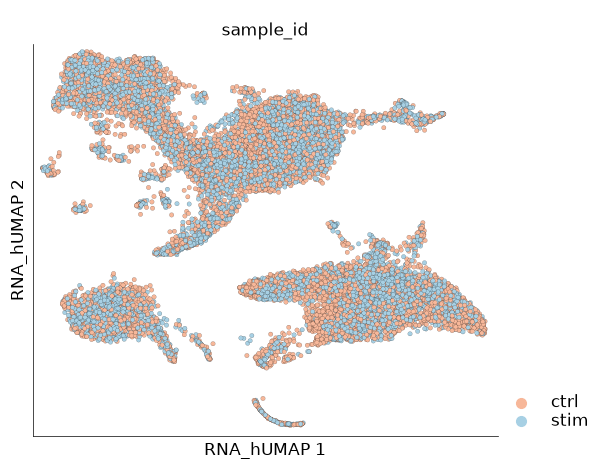

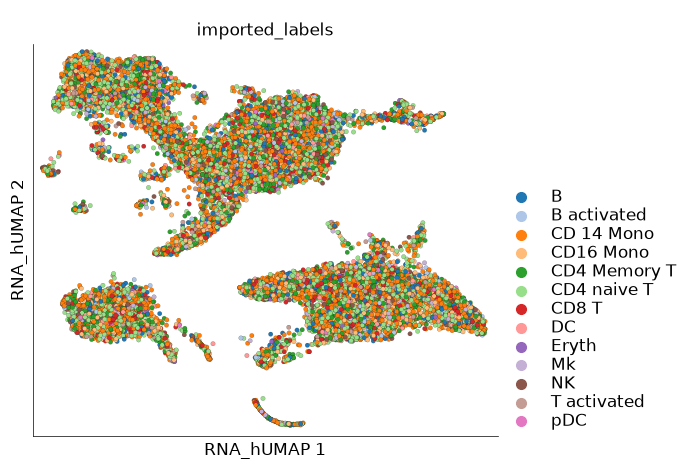

time: 916 ms (started: 2026-06-28 22:59:11 +02:00)


In [25]:
ds.plot_layout(
    layout_key='RNA_hUMAP',
    color_by='sample_id',
    cmap='RdBu',
    legend_ondata=False
)

ds.plot_layout(
    layout_key='RNA_hUMAP',
    color_by='imported_labels',
    legend_ondata=False
)

In [26]:
ds.metric_lisi(
    label_colnames=['sample_id', 'imported_labels'],
    save_result=True,
)

ds.metric_silhouette(res_label='RNA_leiden_cluster')

ds.metric_integration(
    batch_labels=['sample_id', 'imported_labels'],
    metric='ari'
)

INFO: Using the latest knn graph at location: RNA/normed__I__hvgs/reduction__pca__25__is_ctrl/ann__l2__63__63__48__4466/knn__21


INFO: Computing LISI for sample_id


Computing Simpson's Diversity Index:   0%|                                                                    …

INFO: Computing LISI for imported_labels


Computing Simpson's Diversity Index:   0%|                                                                    …

INFO: Using the latest knn graph at location: RNA/normed__I__hvgs/reduction__pca__25__is_ctrl/ann__l2__63__63__48__4466/knn__21 for assay: RNA


INFO: Loaded existing ANN stream from RNA/normed__I__hvgs/reduction__pca__25__is_ctrl/ann__l2__63__63__48__4466


ERROR: Cluster labels not found for RNA_RNA_leiden_cluster


-3.705291026995729e-06

time: 15.7 s (started: 2026-06-28 22:59:12 +02:00)
